In [69]:
#my imports for evalution timseries and data handling

import warnings
warnings.filterwarnings("ignore")

# Data handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Time series evaluation
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("All imports successful!")

All imports successful!


In [70]:
#Loading the dataset and preprocessing

df = pd.read_csv('Retail.csv')
df['date'] = pd.to_datetime(df['date'])

df = df.groupby('date')['sales'].sum().reset_index()
df.set_index('date', inplace=True)

row_count = len(df)
print(f"Dataset loaded successfully with {row_count} rows.")

df.head()


Dataset loaded successfully with 1684 rows.


,sales
date,
2013-01-01,2511.618999
2013-01-02,496092.417944
2013-01-03,361461.231124
2013-01-04,354459.677093
2013-01-05,477350.121229


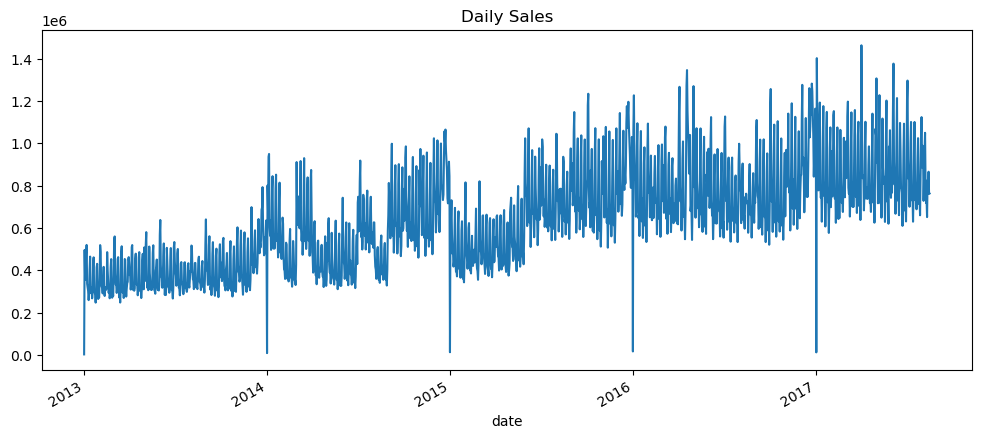

In [71]:
# visualize the sales data and check for trends and seasonality

df['sales'].plot(figsize=(12, 5), title= 'Daily Sales')

plt.show()

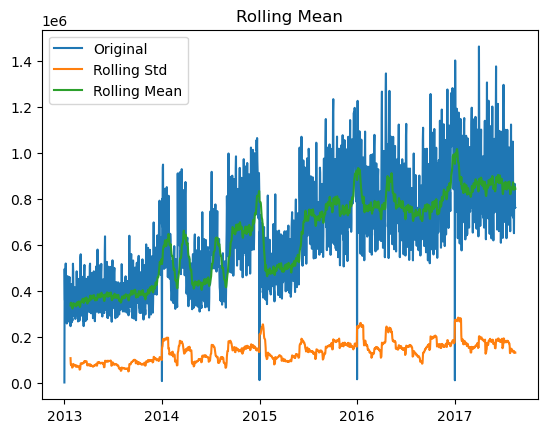

In [72]:
#Check stationarity of the time series using Augmented Dickey-Fuller test

rolling_mean = df['sales'].rolling(window=24).mean()
rolling_std = df['sales'].rolling(window=24).std()


plt.plot(df['sales'], label='Original')
plt.plot(rolling_std, label='Rolling Std')
plt.plot(rolling_mean, label='Rolling Mean')
plt.legend()
plt.title('Rolling Mean')
plt.show()




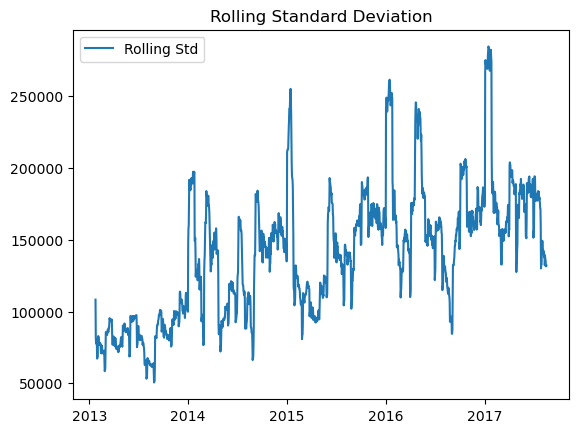

In [73]:
rolling_std = df['sales'].rolling(window=24).std()

plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title('Rolling Standard Deviation')
plt.show()

In [74]:
# Perform Augmented Dickey-Fuller test

result = adfuller(df['sales'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))
    
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

ADF Statistic: -2.616196
p-value: 0.089696
Critical Values:
	1%: -3.434
	5%: -2.863
	10%: -2.568
The time series is non-stationary.


In [75]:
# transform the data to make it stationary

df_log = np.log(df['sales'])
df_diff = df_log.diff().dropna()

result = adfuller(df_diff)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))
    
if result[1] < 0.05:
    print("Data transformed to make it stationary.")
else:
    print("The time series is non-stationary.")



ADF Statistic: -11.119295
p-value: 0.000000
Critical Values:
	1%: -3.434
	5%: -2.863
	10%: -2.568
Data transformed to make it stationary.


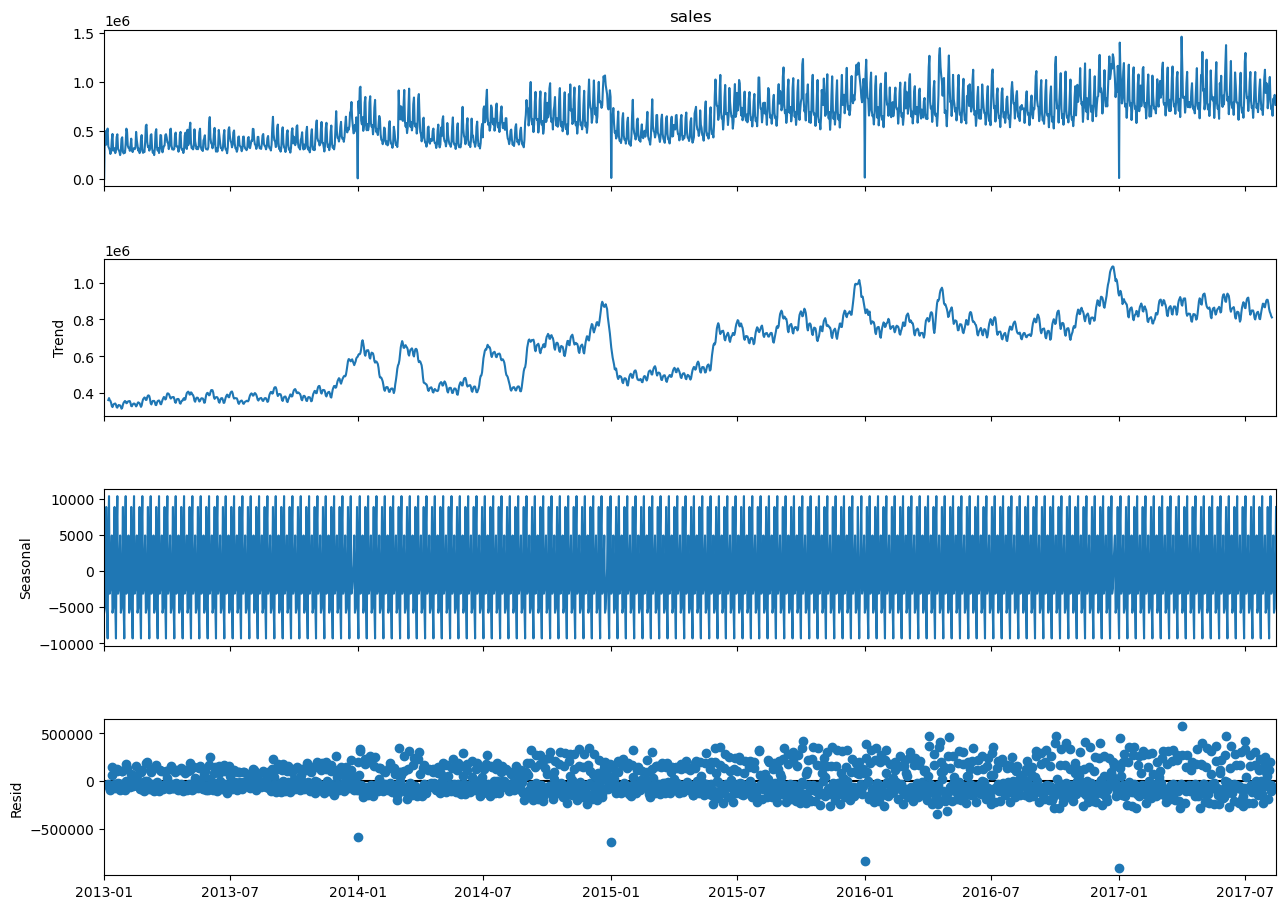

In [76]:
# seasonal decomposition to check for seasonality, trend, and noise

decomposition = seasonal_decompose(df['sales'], model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.show()

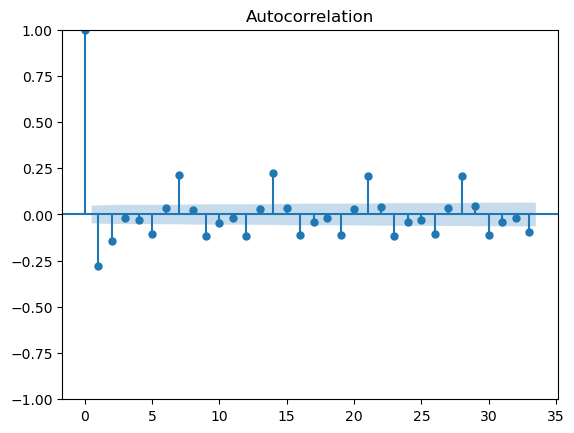

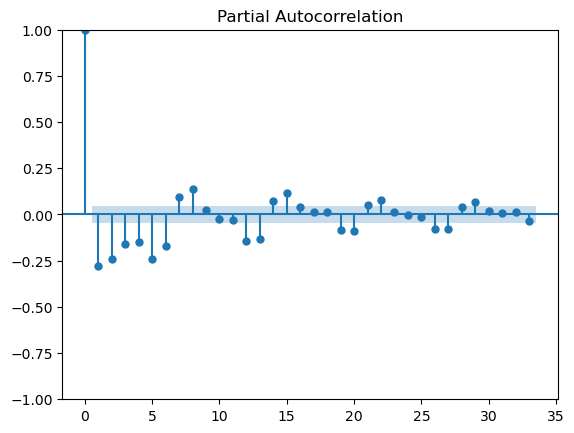

In [77]:
# plot ACF and PACF to determine the order of ARIMA model
# acf and pacf plots to determine p and q (p = AR term, q = MA term)

plot_acf(df_diff)
plot_pacf(df_diff)
plt.show()

In [78]:
# split the data into training and testing sets

train = df[:'2015']
test = df['2016':]

In [79]:
# Fit the ARIMA model
#p = 1 (AR term), d = 1 (differencing), q = 1 (MA term)

model = ARIMA(train['sales'], order=(1, 1, 1))
model_fit = model.fit()

In [80]:
#forecast the sales for the test period

forecast = model_fit.forecast(steps=len(test))

In [81]:
#evaluate the model using MAE and RMSE (MAE = mean absolute error, RMSE = root mean squared error)

mae = mean_absolute_error(test['sales'], forecast)
rmse = np.sqrt(mean_squared_error(test['sales'], forecast))

print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

Mean Absolute Error: 175435.09414809485
Root Mean Squared Error: 204657.06171860886


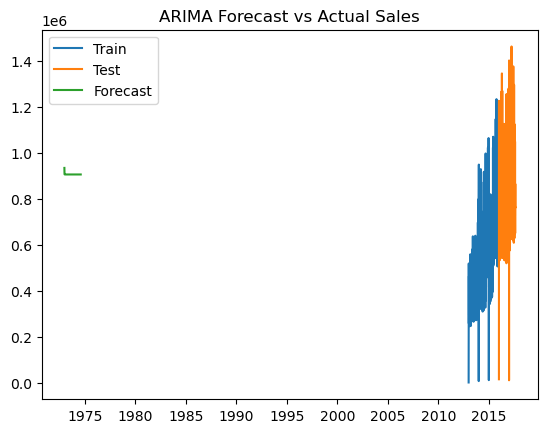

In [83]:
# plot results

plt.Figure(figsize=(12, 5))
plt.plot(train['sales'], label='Train')
plt.plot(test['sales'], label='Test')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.title('ARIMA Forecast vs Actual Sales')
plt.show()